# N-sweep / D-sweep SAGD heatmap grid

Discovers every completed run under `scripts/run/data/` matching the `run_nsweep.sh` naming scheme (`{norm}_D{d}_n{n}/D{d}_N{n}_T{T}`) and plots a grid of SAGD distance-matrix heatmaps: **columns = dimension `d`**, **rows = `n_samples`**. Cells for a (d, n) combination that hasn't been run yet (or is still in progress) are left blank.

Currently `run_nsweep.sh` only sweeps `n_samples` at a fixed `D=1024`, so the grid will show a single populated column until more dimensions are run under the same naming scheme -- no notebook changes needed when that happens, just re-run it.

In [1]:
import re
from pathlib import Path

import numpy as np
import joblib
import matplotlib.pyplot as plt

from lib.ou_model import find_third_phase_onset
from lib.viz.plotting import _draw_sagd_heatmap_with_prob


## Discover runs

Parses `NORM` and `T` out of `run_nsweep.sh` (assumed fixed across the sweep), then finds every `{NORM}_D{d}_n{n}` experiment directory on disk and checks whether its pipeline outputs are complete.

In [2]:
NSWEEP_SCRIPT = Path("../scripts/run/run_nsweep.sh")
NSWEEP_DATA_ROOT = Path("../data")


def parse_bash_vars(script_path: Path) -> dict:
    """Pull simple `VAR=value` / `VAR="value"` assignments out of the sweep script."""
    text = script_path.read_text()
    values = dict(re.findall(r'^(\w+)=([0-9.]+)\s*$', text, flags=re.MULTILINE))
    values.update(re.findall(r'^(\w+)="([^"]*)"\s*$', text, flags=re.MULTILINE))
    return values


cfg = parse_bash_vars(NSWEEP_SCRIPT)
NORM = cfg["NORM"]
T = float(cfg["T"])

# history.jbl is deliberately excluded: it's ~200 MB per run and we no longer
# read it here (snapshot times come from CTDs.jbl, mu from the sweep script).
REQUIRED_FILES = ["Ws.jbl", "CTDs.jbl", "SAGD.jbl", "clusters.jbl"]

# `run_nsweep.sh` sweeps *all* dimensions in `DS` within a single experiment, so
# each experiment dir is named `{NORM}_D{DS}_n{n}` -- where `{DS}` is the whole
# space-separated dimension list -- and holds one `D{d}_N{n}_T{T}` subdirectory
# per dimension. So we match the experiment dir by `n` only and read the
# individual dimensions off the inner run subdirectories.
EXP_PATTERN = re.compile(rf"^{re.escape(NORM)}_D.*_n(\d+)$")
RUN_PATTERN = re.compile(rf"^D(\d+)_N(\d+)_T{int(T)}$")

run_dirs = {}  # (d, n_samples) -> run_dir
for exp_dir in sorted(p for p in NSWEEP_DATA_ROOT.iterdir() if p.is_dir()):
    m = EXP_PATTERN.match(exp_dir.name)
    if not m:
        continue
    n = int(m.group(1))
    for run_dir in sorted(p for p in exp_dir.iterdir() if p.is_dir()):
        rm = RUN_PATTERN.match(run_dir.name)
        if not rm:
            continue
        d, n_dir = int(rm.group(1)), int(rm.group(2))
        assert n_dir == n, f"n mismatch: {run_dir} has N={n_dir} under n{n} experiment"
        missing = [f for f in REQUIRED_FILES if not (run_dir / f).exists()]
        if missing:
            print(f"Skipping D={d}, n_samples={n}: run not finished yet (missing {missing}) at {run_dir}")
            continue
        run_dirs[(d, n)] = run_dir

d_list = sorted({d for d, _ in run_dirs})
n_list = sorted({n for _, n in run_dirs})
print(f"Discovered grid: dimensions={d_list}, n_samples={n_list}")


Discovered grid: dimensions=[256, 1024, 4096], n_samples=[1000, 2000, 4000]


## Load data

One entry per completed `(d, n_samples)` combination; missing combinations simply aren't keys in `grid_data` and are left blank in the plot.

In [3]:
grid_data = {}
std = 1.0  # bimodal_gaussian std used throughout the sweep
mu = float(cfg["MU"])  # constant across the sweep (read from run_nsweep.sh)

for (d, n), run_dir in run_dirs.items():
    breakpoints = joblib.load(run_dir / "clusters.jbl")
    ctds = joblib.load(run_dir / "CTDs.jbl")
    # Snapshot times are stored in the (lightweight) CTDs params as `ts`, so we
    # avoid deserializing the ~200 MB history.jbl just to read them.
    snaps = np.asarray(ctds["params"]["ts"])

    grid_data[(d, n)] = dict(
        W=joblib.load(run_dir / "SAGD.jbl"),
        time_snaps=snaps,
        ts=None,
        tsagd=snaps[breakpoints[0]],
        tstar=find_third_phase_onset(ctds["CTDs"], snaps),
        ctds=ctds,
        mu=mu,
    )

print(f"Loaded {len(grid_data)} / {len(run_dirs)} (d, n_samples) combinations")


Loaded 9 / 9 (d, n_samples) combinations


## Grid plot

Reuses `lib.viz.plotting._draw_sagd_heatmap_with_prob` per cell instead of redrawing the heatmap here. That helper ties its title and the theoretical same-cluster probability curve `φ(t)` to the same `d` argument -- which is exactly right in this grid, since `d` genuinely varies by column (unlike the earlier n_samples-only row plot, where `d` was fixed and had to be decoupled from the label).

In [4]:
def plot_sagd_heatmap_grid(
        grid_data, d_list, n_list, std,
        distance='SAGD', show_prob=True, show_legend=True,
        clipping=True, save_fig_path=None,
):
    """
    Grid of SAGD-distance heatmaps: columns = dimension `d`, rows = `n_samples`.
    `grid_data` maps (d, n_samples) -> dict with keys W, time_snaps, ts,
    tsagd, tstar, ctds, mu. Missing (d, n_samples) combinations are left blank.
    """
    if not d_list or not n_list:
        raise ValueError("d_list / n_list is empty -- no completed runs to plot.")

    nrows, ncols = len(n_list), len(d_list)
    fig, axes = plt.subplots(
        nrows=nrows, ncols=ncols,
        figsize=(6 * ncols, 9.5 * nrows),
        gridspec_kw={'wspace': 0.5, 'hspace': 0.6},
        squeeze=False,
    )

    for row, n in enumerate(n_list):
        for col, d in enumerate(d_list):
            ax = axes[row, col]
            cell = grid_data.get((d, n))
            if cell is None:
                ax.axis('off')
                ax.text(0.5, 0.5, f"D={d}, N={n}\n(no data)",
                        ha='center', va='center', fontsize=11, color='gray',
                        transform=ax.transAxes)
                continue

            _draw_sagd_heatmap_with_prob(
                ax_hm=ax,
                W=cell["W"],
                time_vector=cell["time_snaps"],
                d=d,
                mu=cell["mu"],
                std=std,
                ts=cell["ts"],
                tsagd=cell["tsagd"],
                t_star=cell["tstar"],
                show_ylabel=(col == 0),
                show_legend=show_legend,
                show_prob=show_prob,
                distance=distance,
                ctds=cell["ctds"],
                model='synthetic',
                clipping=clipping,
            )
            if col == 0:
                ax.set_ylabel(f"N={n}\nTime", fontsize=12)

    if save_fig_path:
        Path(save_fig_path).parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_fig_path, dpi=300, bbox_inches='tight')
    plt.show()


## Plot

KeyboardInterrupt: 

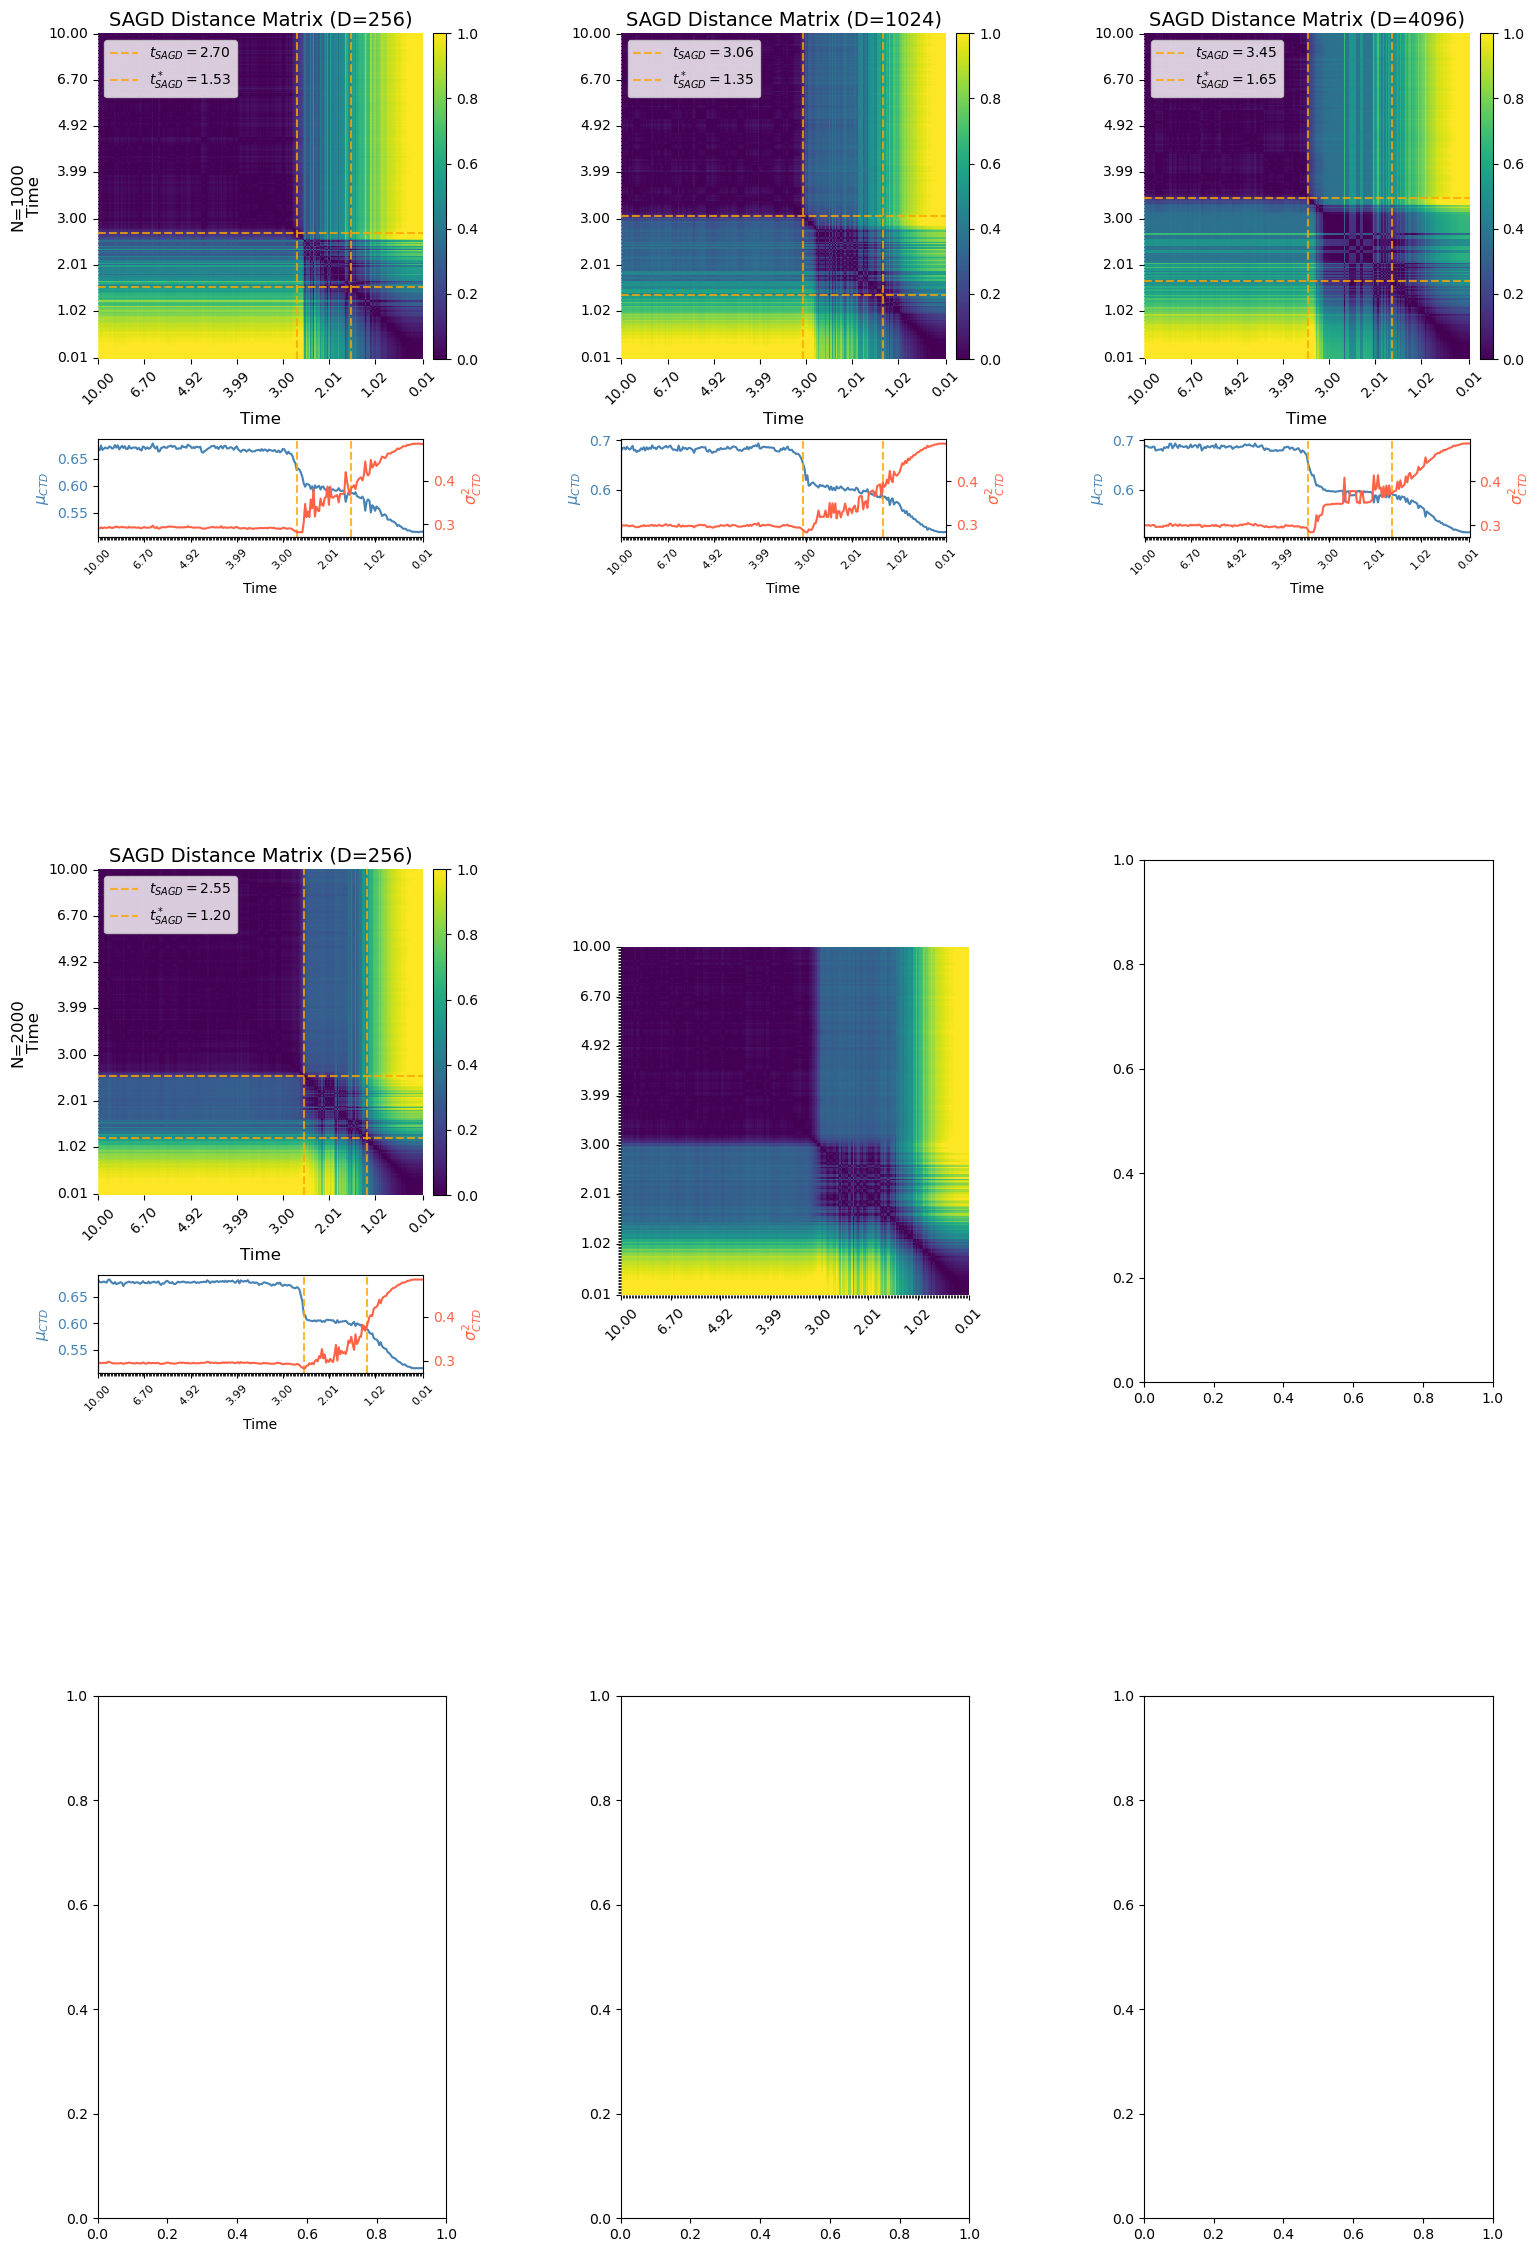

In [5]:
plot_sagd_heatmap_grid(
    grid_data=grid_data,
    d_list=d_list,
    n_list=n_list,
    std=std,
    distance='SAGD',
    show_prob=False,
    save_fig_path='figs/sagd_heatmap_grid_d_x_nsamples.png',
)


## Animated distributions per time step

For a chosen `(d, n_samples)`, animate how three per-snapshot distributions evolve along the
diffusion trajectory (`t = T -> 0`):

1. **Raw CTD** — the un-normalized Commute-Time-Distance distribution over all node pairs
   (`CTDs.jbl -> ctds`). Spans many orders of magnitude, so it's drawn on a **log x-axis**.
2. **Normalized CTD** — the same distribution after `--norm_type` normalization
   (`CTDs.jbl -> norm_ctds`); this is what the SAGD Wasserstein distance actually compares.
3. **Euclidean distance** — the distribution of pairwise Euclidean distances between the actual
   sample positions at that snapshot (computed from `history.jbl`).

The raw/normalized CTDs come straight from the cached `CTDs.jbl` (already compressed to
`n_bins` equal-frequency quantiles unless the run used `--keep_raw_ctds`). The Euclidean
distances aren't cached by the pipeline, so we compute them once from the (large) `history.jbl`
and cache them next to the other outputs as `euclid_dists.jbl` — subsequent runs read only the
small cache. Histogramming an equal-frequency-quantile array recovers the distribution shape,
so all three panels are directly comparable.

Histograms use `bins=20000`. Note the cached CTD arrays hold only `n_bins` (5000) quantile
points each, so beyond ~5000 bins most bins are empty by construction -- raising the
resolution further needs the pipeline re-run with a larger `--n_bins`.

The Euclidean panel is clipped to `euclid_xlim=(0, 30)`. That window is dimension-dependent:
pairwise distances in `d` dimensions concentrate around `sqrt(2*d)`, so it covers most of the
mass at `d=256` (~86%) but **nothing** at `d=1024`, where distances start around 40. Widen
`euclid_xlim` when animating higher `d`.

The player exposes a **frame slider plus play/step buttons** (`FuncAnimation.to_jshtml`), so the
time step can be scrubbed manually or played through — no extra widget dependency required.

In [8]:
from scipy.spatial.distance import pdist
from joblib import Parallel, delayed

from lib.stats import compress_equal_frequency

EUCLID_FILE = "euclid_dists.jbl"


def _snapshot_euclid_quantiles(points: np.ndarray, n_bins: int) -> np.ndarray:
    """All pairwise Euclidean distances at one snapshot, compressed to `n_bins`
    equal-frequency quantiles (same scheme the pipeline uses for CTDs)."""
    return compress_equal_frequency(pdist(np.asarray(points), metric="euclidean"), n_bins)


def get_euclidean_quantiles(run_dir: Path, n_bins: int = 5000, n_jobs: int = 16) -> dict:
    """Per-snapshot pairwise-Euclidean-distance distributions for one run.

    Cached as `euclid_dists.jbl` next to the other pipeline outputs, so the
    large `history.jbl` is deserialized only the first time. Returns a dict
    mapping snapshot time -> compressed quantile array, ordered T -> 0.
    """
    cache = run_dir / EUCLID_FILE
    if cache.exists():
        return joblib.load(cache)["euclid"]

    hist = joblib.load(run_dir / "history.jbl")["history"]  # {t: (N, d) array}
    ts = list(hist.keys())
    dists = Parallel(n_jobs=n_jobs)(
        delayed(_snapshot_euclid_quantiles)(hist[t], n_bins) for t in ts
    )
    euclid = dict(zip(ts, dists))
    joblib.dump(
        {"euclid": euclid, "params": {"ts": ts, "n_bins": n_bins}},
        cache,
        compress=3,
    )
    return euclid


In [9]:
import matplotlib.animation as animation
from IPython.display import HTML

# (title, key, x-axis color, log-x?) for the three distribution panels.
_PANELS = [
    ("Raw CTD",            "ctds",      "steelblue", True),
    ("Normalized CTD",     "norm_ctds", "seagreen",  False),
    ("Euclidean distance", "euclid",    "indianred", False),
]


def _panel_edges(dists, bins, logx, xlim=None):
    """Fixed histogram bin edges spanning every snapshot, so the bars don't
    shift horizontally during the animation. `xlim` pins the range explicitly
    instead of deriving it from the data."""
    if xlim is not None:
        lo, hi = xlim
    else:
        lo = min(a.min() for a in dists)
        hi = max(a.max() for a in dists)
    if logx:
        lo = max(lo, 1e-12)
        return np.logspace(np.log10(lo), np.log10(hi), bins + 1)
    return np.linspace(lo, hi, bins + 1)


def animate_distributions(d, n, stride=2, bins=5000, euclid_xlim=(30, 60),
                          n_jobs=16, fps=6, save_path=None):
    """Animated raw-CTD / normalized-CTD / Euclidean-distance distributions for
    the completed run `(d, n_samples)`, one frame per snapshot time.

    Returns an ``IPython.display.HTML`` player (frame slider + play/step
    controls) so the time step can be scrubbed manually or played through.
    `stride` sub-samples snapshots to keep the embedded animation small.
    `euclid_xlim` clips the Euclidean panel to a fixed window (the CTD panels
    still auto-scale); note the useful window scales with `d`, since pairwise
    distances in d dimensions concentrate around sqrt(2*d).

    If `save_path` is given, the animation is also written to disk (parent dirs
    created as needed). The format follows the extension:
      * `.gif`          -> rendered frames via the pillow writer;
      * `.html`/`.htm`  -> the self-contained scrubbable jshtml player.
    (`.mp4` needs ffmpeg, which isn't installed here -- use `.gif`.)
    """
    if (d, n) not in grid_data:
        raise KeyError(
            f"No completed run for (d={d}, n_samples={n}). "
            f"Available: {sorted(grid_data)}"
        )

    cell = grid_data[(d, n)]
    ctds = cell["ctds"]["CTDs"]                       # {t: {'ctds', 'norm_ctds'}}
    euclid = get_euclidean_quantiles(run_dirs[(d, n)], n_jobs=n_jobs)
    snaps = list(ctds.keys())                          # ordered T -> 0
    assert list(euclid.keys()) == snaps, "CTD / Euclidean snapshot times differ"
    tsagd, tstar = cell["tsagd"], cell["tstar"]

    # Pre-materialize each panel's per-snapshot distribution + fixed bins/limits.
    sources = {"ctds": lambda t: np.asarray(ctds[t]["ctds"]),
               "norm_ctds": lambda t: np.asarray(ctds[t]["norm_ctds"]),
               "euclid": lambda t: np.asarray(euclid[t])}
    panel_xlim = {"euclid": euclid_xlim}
    panel_data, panel_edges, panel_ymax = [], [], []
    for _title, key, _c, logx in _PANELS:
        dists = [sources[key](t) for t in snaps]
        edges = _panel_edges(dists, bins, logx, panel_xlim.get(key))
        ymax = max(np.histogram(a, bins=edges)[0].max() for a in dists)
        if ymax == 0:
            print(f"warning: no {key} values fall inside {panel_xlim[key]} -- "
                  f"panel will be empty (try a wider euclid_xlim for d={d})")
        panel_data.append(dists)
        panel_edges.append(edges)
        panel_ymax.append(max(ymax, 1) * 1.08)

    frames = list(range(0, len(snaps), stride))
    if frames[-1] != len(snaps) - 1:
        frames.append(len(snaps) - 1)                  # always end at t -> 0

    fig = plt.figure(figsize=(16, 5))
    gs = fig.add_gridspec(2, 3, height_ratios=[1, 9], hspace=0.55, wspace=0.28)
    ax_time = fig.add_subplot(gs[0, :])
    axes = [fig.add_subplot(gs[1, c]) for c in range(3)]

    # Static timeline strip: regime boundaries + a moving "current time" marker.
    T_max = max(snaps)
    ax_time.set_xlim(0, T_max)
    ax_time.set_ylim(0, 1)
    ax_time.set_yticks([])
    ax_time.set_xlabel("diffusion time  t  (T → 0)")
    ax_time.axvline(tsagd, color="darkcyan", lw=2, label=fr"$t_{{sagd}}$={tsagd:.2f}")
    ax_time.axvline(tstar, color="darkorange", lw=2, ls="--", label=fr"$t^*$={tstar:.2f}")
    ax_time.legend(loc="center left", bbox_to_anchor=(1.005, 0.5),
                   fontsize=8, frameon=False)
    time_marker = ax_time.axvline(T_max, color="red", lw=2.5)

    def draw(frame_idx):
        t = snaps[frame_idx]
        time_marker.set_xdata([t, t])
        for ax, dists, edges, ymax, (title, _key, color, logx) in zip(
                axes, panel_data, panel_edges, panel_ymax, _PANELS):
            ax.clear()
            ax.hist(dists[frame_idx], bins=edges, color=color, alpha=0.85)
            if logx:
                ax.set_xscale("log")
            ax.set_xlim(edges[0], edges[-1])
            ax.set_ylim(0, ymax)
            ax.set_title(title, fontsize=11)
            ax.set_xlabel("distance")
            ax.set_ylabel("count (quantile bins)")
        regime = ("noise" if t > tsagd else
                  "SAGD onset" if t > tstar else "resolved clusters")
        fig.suptitle(f"D={d}, N={n}   |   t = {t:.2f}   |   regime: {regime}",
                     fontsize=13, y=1.0)
        print("Drew frame")

    anim = animation.FuncAnimation(
        fig, lambda k: draw(frames[k]), frames=len(frames), interval=1000 / fps
    )

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        suffix = save_path.suffix.lower()
        if suffix == ".gif":
            anim.save(save_path, writer="pillow", fps=fps)
        elif suffix in (".html", ".htm"):
            save_path.write_text(anim.to_jshtml(fps=fps))
        else:
            plt.close(fig)
            raise ValueError(
                f"Unsupported save extension '{suffix}'. Use '.gif' or '.html' "
                "('.mp4' requires ffmpeg, which isn't installed)."
            )
        print(f"Saved animation -> {save_path}")

    html = HTML(anim.to_jshtml(fps=fps))
    plt.close(fig)
    return html


In [10]:
# Pick any completed (d, n_samples); first call builds & caches euclid_dists.jbl
# for that run (reads the large history.jbl once), later calls are fast.
print("available (d, n_samples):", sorted(grid_data))

# `save_path` also writes the animation to disk: '.gif' (rendered frames) or
# '.html' (self-contained scrubbable player). Both land under figs/.
animate_distributions(d=1024, n=4000, 
                      save_path="figs/dist_animation_D256_N1000.html")


available (d, n_samples): [(256, 1000), (256, 2000), (256, 4000), (1024, 1000), (1024, 2000), (1024, 4000), (4096, 1000), (4096, 2000), (4096, 4000)]
Drew frame
Drew frame
Drew frame
Drew frame
Drew frame
Drew frame
Drew frame
Drew frame
Drew frame
Drew frame
Drew frame
Drew frame
Drew frame
Drew frame
Drew frame
Drew frame
Drew frame
Drew frame
Drew frame
Drew frame
Drew frame
Drew frame
Drew frame
Drew frame
Drew frame
Drew frame
Drew frame
Drew frame
Drew frame
Drew frame
Drew frame
Drew frame
Drew frame
Drew frame
Drew frame
Drew frame
Drew frame
Drew frame
Drew frame
Drew frame
Drew frame
Drew frame
Drew frame
Drew frame
Drew frame
Drew frame
Drew frame
Drew frame
Drew frame
Drew frame
Drew frame
Drew frame
Drew frame
Drew frame
Drew frame
Drew frame
Drew frame
Drew frame
Drew frame
Drew frame
Drew frame
Drew frame
Drew frame
Drew frame
Drew frame
Drew frame
Drew frame
Drew frame
Drew frame
Drew frame
Drew frame
Drew frame
Drew frame
Drew frame
Drew frame
Drew frame
Drew frame
Dre